# 01 - Begin Analysis

Path to Dataset Dict Made in Notebook 01

In [32]:
symptom = 'REPRODUCTION_AD_FX_Q4'
roi_path = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/memory_map/convergent_memory_map.nii'
dict_path = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/results/notebook_01/alzheimer/conn/tmp/dataset_dict.json'   #DBS
out_dir = f'/Users/cu135/hires_backdrops/test'

What correlation method would you like to use?
- Pearson is very fast, but depends on linearity and is sensitive to outliers
- Spearman is slower, but much more robust

In [33]:
correlation = 'spearman'

Prep Data Objects and Store Them for Future Reference

In [34]:
from calvin_utils.neuroimaging_utils.ccm_utils.stat_utils import CorrelationCalculator
from calvin_utils.neuroimaging_utils.ccm_utils.npy_utils import DataLoader
data_loader = DataLoader(data_dict_path=dict_path)
correlation_calculator = CorrelationCalculator(method=correlation, verbose=False)
corr_map_dict = correlation_calculator.generate_correlation_maps(data_loader)

Evaluating Advance_AD_DBS_FORNIX


# 02 - Use LOOCV to Train a Convergent Map on N-1 Datasets, Then Test it on the Nth dataset

Generate the Convergent Maps and Save the Individual Correlation Maps

In [35]:
from calvin_utils.neuroimaging_utils.ccm_utils.convergent_loocv import LOOCVAnalyzer
loocv_analyzer = LOOCVAnalyzer(corr_map_dict, data_loader, 
                               similarity='spatial_correl',
                               method=correlation,
                               out_dir=out_dir + f'/{symptom}',
                               datasets_to_flip = [],
                               mask_path='/Users/cu135/Software_Local/calvin_utils_project/circuit_pyper/resources/MNI152_T1_2mm_brain_mask.nii',
                               roi_path=roi_path,
                               ylabel=symptom.capitalize())

Removing NaNS from self.coor_map_dict.


Run LOOCV

No training required--loading user-defined ROI file


<Figure size 432x432 with 0 Axes>

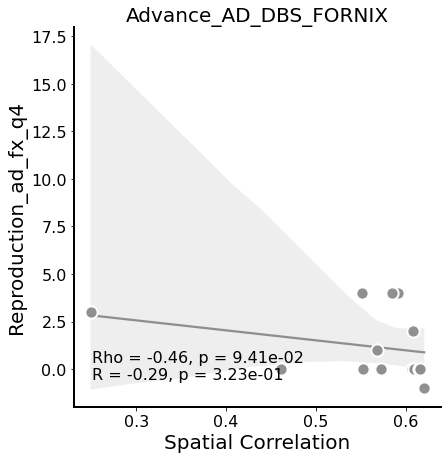

In [36]:
loocv_analyzer.run()

That's all

-Calvin